<a href="https://colab.research.google.com/github/pbpallavi27-bit/Amb2162_Pallavi-P-Bhat/blob/main/WeedDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving dataset.zip to dataset.zip


In [2]:
import zipfile

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [3]:
import os
print(os.listdir("/content/"))

['.config', 'dataset.zip', 'WeedCrop.v1i.yolov5pytorch', 'sample_data']


In [4]:
base_path = "/content/dataset/WeedCrop.v1i.yolov5pytorch"

In [5]:
import os
import shutil

# Correcting the base_path as it was incorrectly set in a previous cell
base_path = "/content/WeedCrop.v1i.yolov5pytorch"

def convert(split):
    images_path = os.path.join(base_path, split, "images")
    labels_path = os.path.join(base_path, split, "labels")

    output_path = f"/content/data/{split}"

    os.makedirs(output_path + "/weed", exist_ok=True)
    os.makedirs(output_path + "/crop", exist_ok=True)

    for file in os.listdir(labels_path):
        with open(os.path.join(labels_path, file), "r") as f:
            content = f.read().strip()

        # Skip empty label files
        if not content:
            continue

        img_file = file.replace(".txt", ".jpg")
        img_path = os.path.join(images_path, img_file)

        if not os.path.exists(img_path):
            continue

        label = content.split()[0]

        if label == "0":
            shutil.copy(img_path, output_path + "/crop/")
        elif label == "1":
            shutil.copy(img_path, output_path + "/weed/")

# Run conversion
convert("train")
convert("test")
convert("valid")

print("✅ Conversion Done!")

✅ Conversion Done!


In [6]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/data/train",
    image_size=(128,128),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/data/valid",
    image_size=(128,128),
    batch_size=32
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/data/test",
    image_size=(128,128),
    batch_size=32
)

Found 2368 files belonging to 2 classes.
Found 235 files belonging to 2 classes.
Found 118 files belonging to 2 classes.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers

norm = layers.Rescaling(1./255)

train_data = train_data.map(lambda x,y: (norm(x), y))
val_data = val_data.map(lambda x,y: (norm(x), y))
test_data = test_data.map(lambda x,y: (norm(x), y))

In [8]:
from tensorflow.keras import models

model = models.Sequential([
    layers.Conv2D(32,3,activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9519 - loss: 0.2039 - val_accuracy: 0.9532 - val_loss: 0.1579
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9523 - loss: 0.1498 - val_accuracy: 0.9532 - val_loss: 0.1933
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9523 - loss: 0.1371 - val_accuracy: 0.9532 - val_loss: 0.1501
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9527 - loss: 0.1431 - val_accuracy: 0.9532 - val_loss: 0.1662
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9557 - loss: 0.1247 - val_accuracy: 0.9532 - val_loss: 0.2014
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9590 - loss: 0.1101 - val_accuracy: 0.9532 - val_loss: 0.1357
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9649 - loss: 0.1009 - val_accuracy: 0.9532 - val_loss: 0.2437
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9654 - loss: 0.0897 - val_accuracy: 0.9532 - val_loss

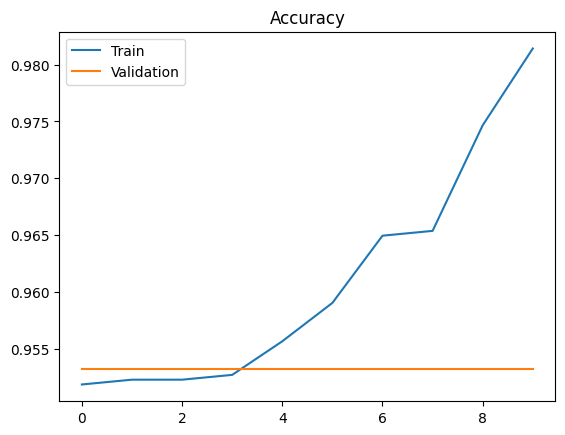

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img = image.img_to_array(img)/255
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)

    if pred[0][0] > 0.5:
        print("🌿 Weed")
    else:
        print("🌱 Crop")

In [12]:
model.save("weed_model.h5")

In [13]:
from tensorflow.keras import models, layers

# Hyperparameters
learning_rate = 0.001
dropout_rate = 0.5

model = models.Sequential([
    layers.Conv2D(32,3,activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),

    layers.Dropout(dropout_rate),  # 🔥 NEW

    layers.Dense(1,activation='sigmoid')
])

In [14]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9443 - loss: 0.2042 - val_accuracy: 0.9532 - val_loss: 0.1578
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9523 - loss: 0.1812 - val_accuracy: 0.9532 - val_loss: 0.1662
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9523 - loss: 0.1570 - val_accuracy: 0.9532 - val_loss: 0.1680
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9523 - loss: 0.1383 - val_accuracy: 0.9532 - val_loss: 0.1747


In [17]:
learning_rate = 0.001
dropout_rate = 0.5
batch_size = 32

In [18]:
learning_rate = 0.0001
dropout_rate = 0.3
batch_size = 64

In [19]:
learning_rate = 0.01
dropout_rate = 0.6

In [20]:
learning_rate = 0.0001
dropout_rate = 0.3
epochs = 20

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_data = train_data.map(lambda x, y: (data_augmentation(x), y))

In [ ]:
#

In [22]:
model.evaluate(test_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.8983 - loss: 0.2094


[0.20943677425384521, 0.8983050584793091]